# NBA Rookie Longevity Prediction
## Objectif
Prédire si un rookie NBA durera **plus de 5 ans** en ligue (`TARGET_5Yrs = 1`) à partir de ses statistiques de première saison.

## Pipeline
```
1. EDA          → comprendre les données
2. Pre-processing → nettoyage + feature engineering
3. Modélisation  → comparaison + optimisation (Pipeline sklearn)
4. Évaluation    → métriques finales sur test set hold-out
5. Sauvegarde    → pipeline complet en joblib
```


---
# 1. Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, roc_auc_score, f1_score,
    precision_recall_curve, roc_curve, auc,
    classification_report
)
from xgboost import XGBClassifier
import joblib
import optuna

RANDOM_STATE = 42


In [2]:
# ─────────────────────────────────────────────
# Chargement du dataset
# ─────────────────────────────────────────────
data = pd.read_csv('nba_logreg.csv')

df = data.copy()

print(f'Shape : {df.shape}')   
print(f'\nAperçu :')
df.head()

Shape : (1340, 21)

Aperçu :


,Name,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0.0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0.0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0.0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1.0
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1.0


In [3]:
print('Types de données :')
print(df.dtypes.value_counts())

print('\nDétail par colonne :')
print(df.dtypes)

Types de données :
float64    19
object      1
int64       1
Name: count, dtype: int64

Détail par colonne :
Name            object
GP               int64
MIN            float64
PTS            float64
FGM            float64
FGA            float64
FG%            float64
3P Made        float64
3PA            float64
3P%            float64
FTM            float64
FTA            float64
FT%            float64
OREB           float64
DREB           float64
REB            float64
AST            float64
STL            float64
BLK            float64
TOV            float64
TARGET_5Yrs    float64
dtype: object


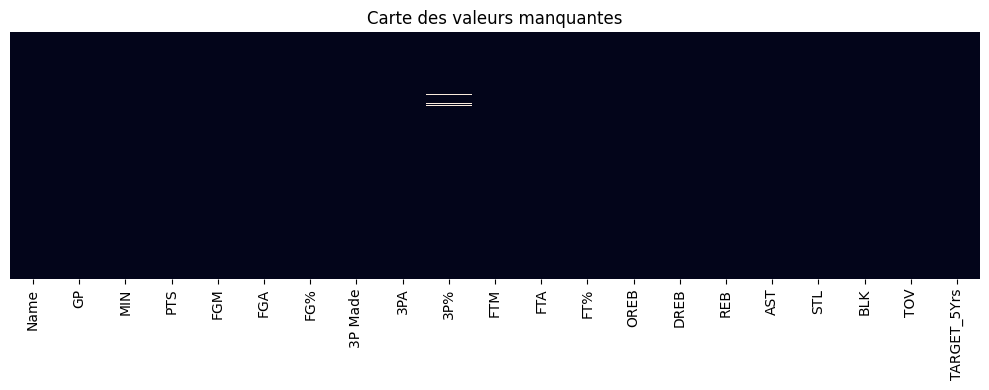

NaN par colonne :
3P%    11
dtype: int64


In [4]:
# ─────────────────────────────────────────────
# Valeurs manquantes
# ─────────────────────────────────────────────
# Heatmap : chaque case blanche = NaN
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title('Carte des valeurs manquantes')
plt.tight_layout()
plt.show()

missing = df.isna().sum().sort_values(ascending=False)
print('NaN par colonne :')
print(missing[missing > 0])

# La colonne 3P% contient des NaN → sera supprimée lors de la feature selection

In [5]:
# ─────────────────────────────────────────────
# Distribution de la variable cible
# ─────────────────────────────────────────────
# 1 = joueur actif après 5 ans, 0 = sorti de la ligue
print('Distribution de TARGET_5Yrs (proportions) :')
print(df['TARGET_5Yrs'].value_counts(normalize=True).round(3))

# Légère prédominance de la classe 1 (~62% vs 38%)


Distribution de TARGET_5Yrs (proportions) :
TARGET_5Yrs
1.0    0.62
0.0    0.38
Name: proportion, dtype: float64


In [6]:
# ─────────────────────────────────────────────
# Séparation positifs / négatifs pour l'analyse visuelle
# ─────────────────────────────────────────────
# Cette séparation est uniquement pour l'EDA (comparaison visuelle)
positive_df = df[df['TARGET_5Yrs'] == 1]   # joueurs qui durent
negative_df = df[df['TARGET_5Yrs'] == 0]   # joueurs qui partent

print(f'Joueurs durables (1) : {len(positive_df)}')
print(f'Joueurs partants (0) : {len(negative_df)}')

Joueurs durables (1) : 831
Joueurs partants (0) : 509


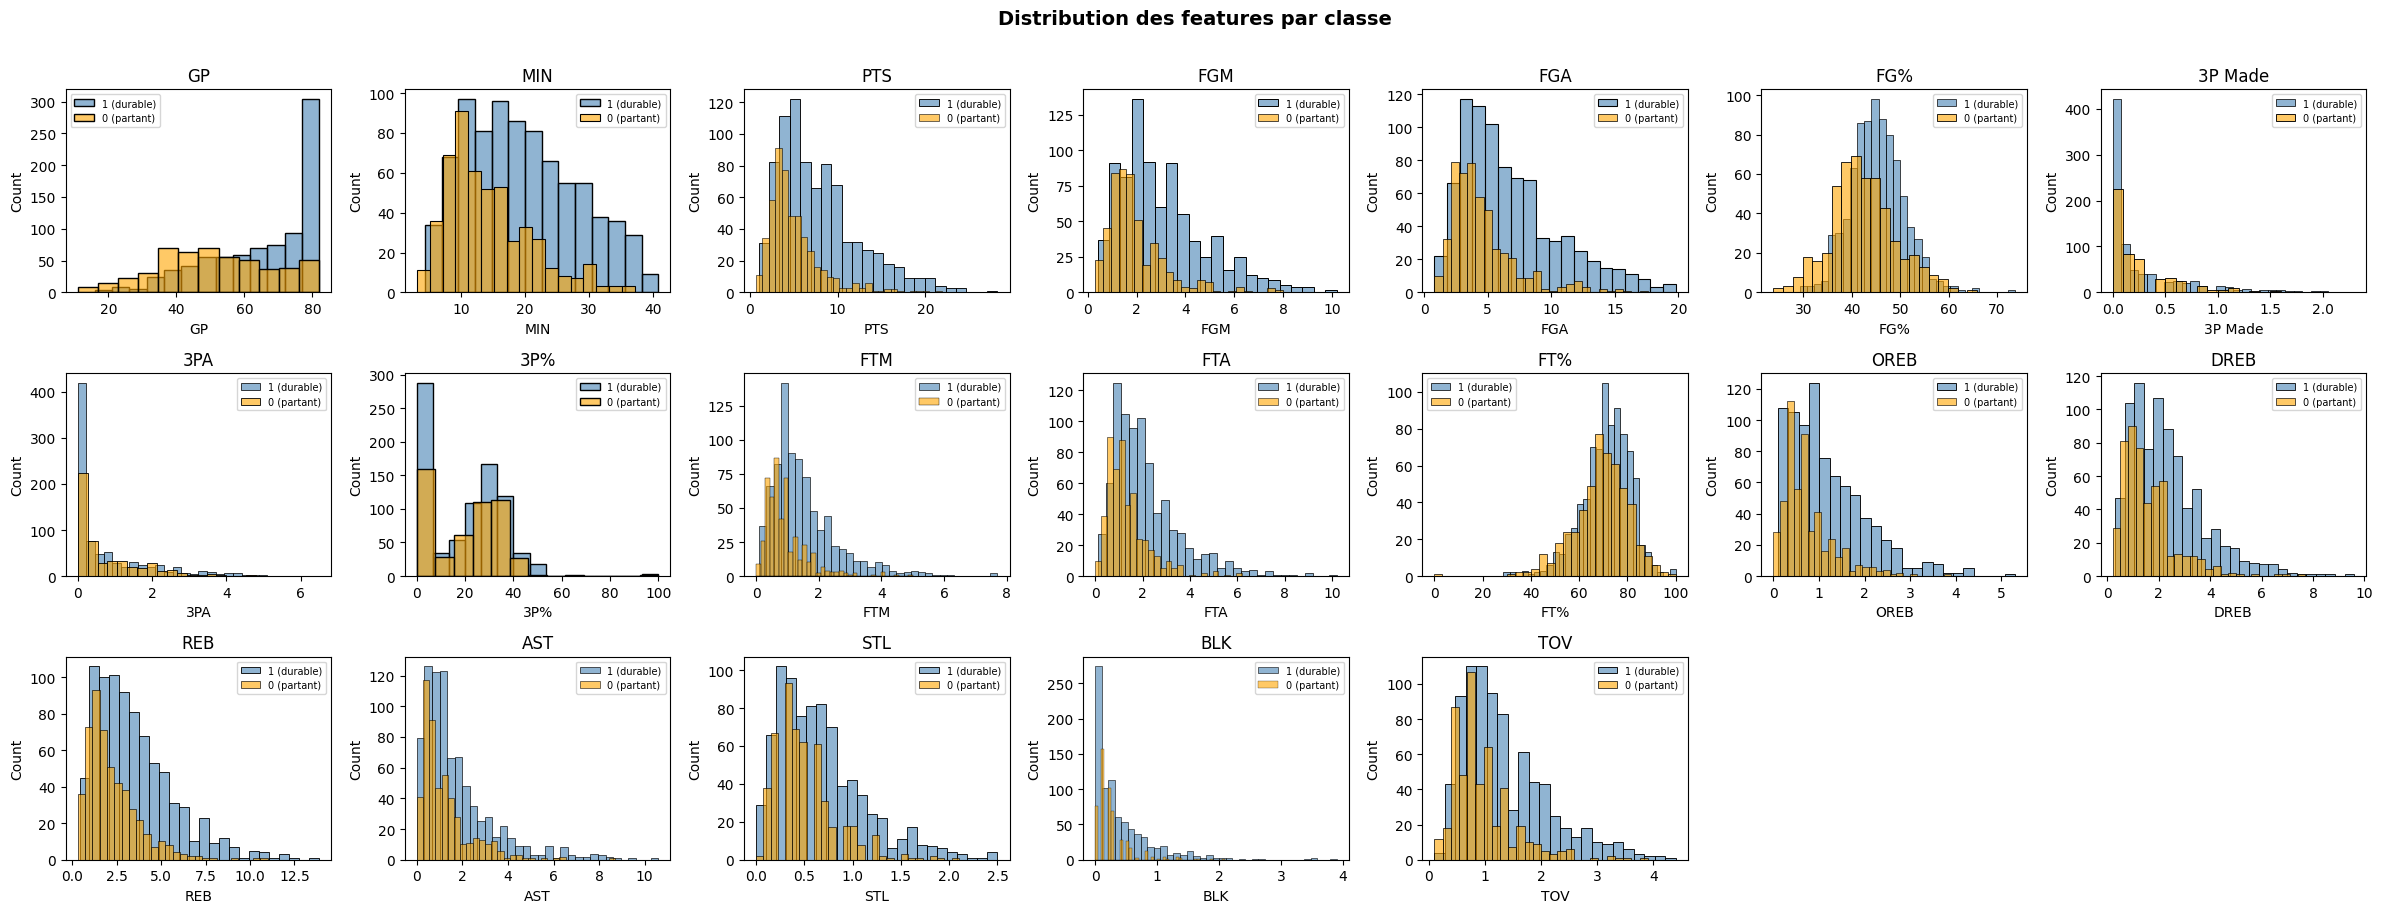

In [7]:
# ─────────────────────────────────────────────
# Histogrammes comparatifs : classe 0 vs classe 1
# ─────────────────────────────────────────────
# identifier visuellement les features les plus discriminantes
cols = df.select_dtypes(['float', 'int']).columns.tolist()
cols = [col for col in cols if col != 'TARGET_5Yrs']

n_cols = 7
n_rows = -(-len(cols) // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(positive_df[col], label='1 (durable)', ax=axes[i], color='steelblue', alpha=0.6)
    sns.histplot(negative_df[col], label='0 (partant)', ax=axes[i], color='orange', alpha=0.6)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des features par classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Observation : GP (games played) semble être la feature la plus discriminante

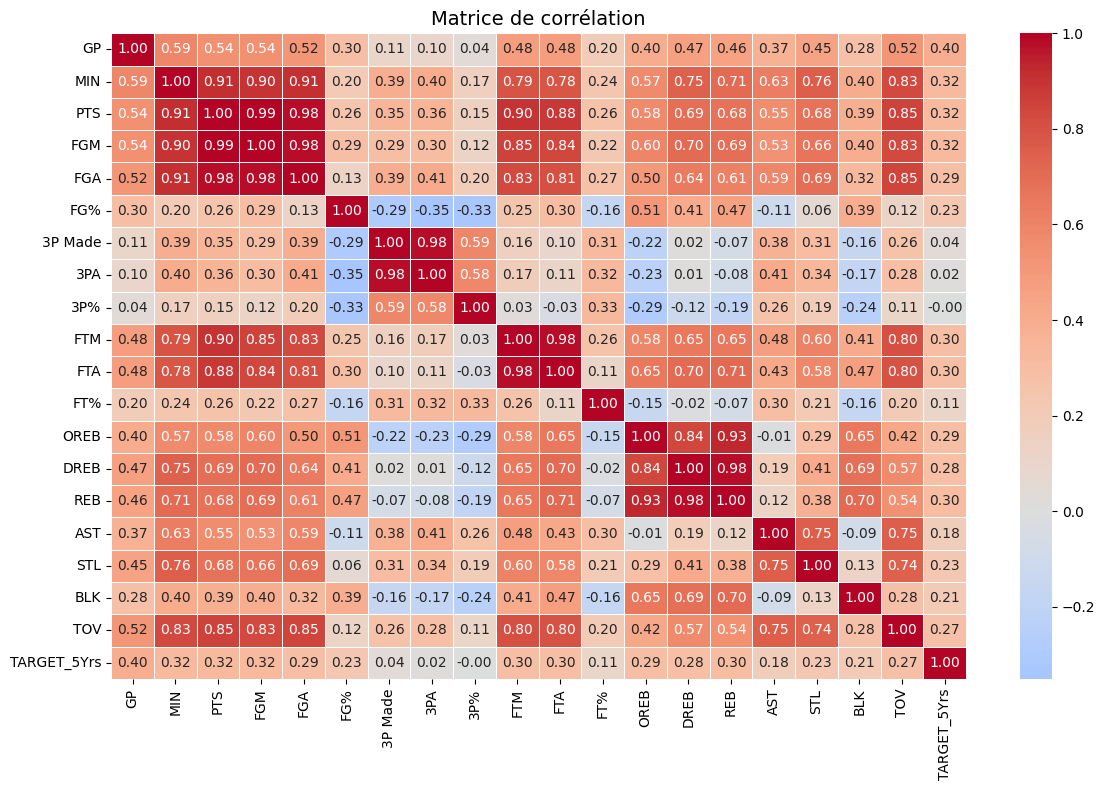

In [8]:
# ─────────────────────────────────────────────
# Matrice de corrélation
# ─────────────────────────────────────────────
# identifier les features redondantes (multicolinéarité)
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.drop(columns=['Name']).corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Matrice de corrélation', fontsize=14)
plt.tight_layout()
plt.show()

# Features très corrélées entre elles (> 0.95) → redondance → à supprimer :
# PTS ↔ FGM ↔ FGA | FTM ↔ FTA | OREB+DREB ↔ REB | 3P Made ↔ 3PA

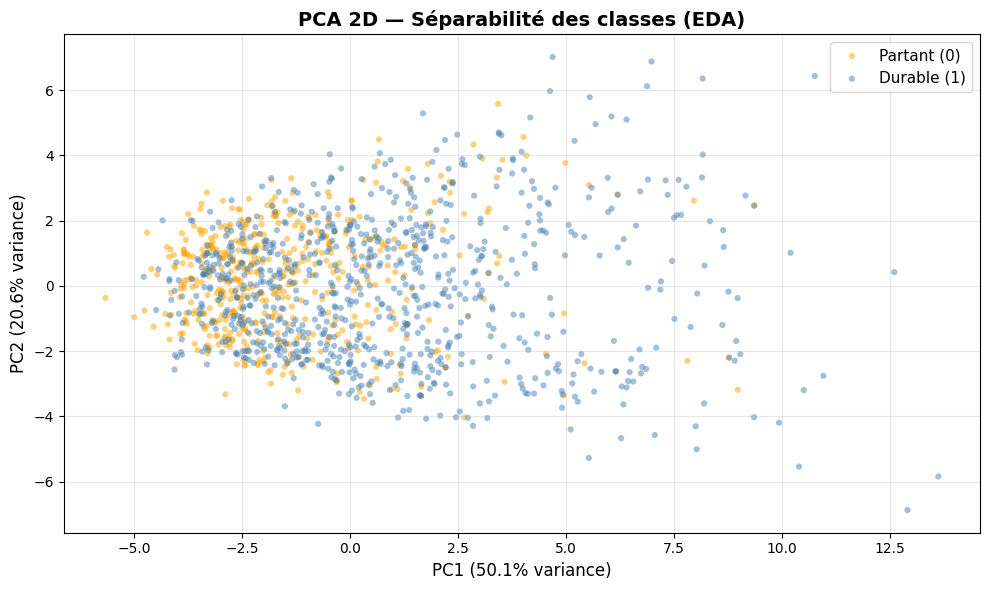

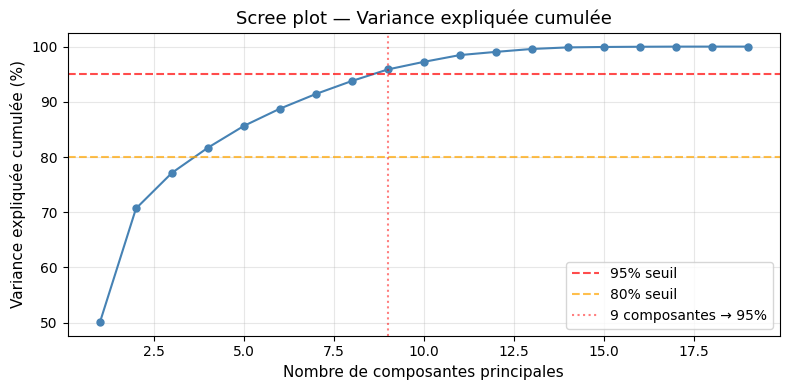


→ Il faut 9 composantes pour capturer 95% de la variance
→ Les classes se chevauchent en 2D : la séparation est non-linéaire
   → justifie l'usage d'un modèle non-linéaire


In [9]:
# ─────────────────────────────────────────────
# 1.7 PCA — Visualisation 2D des données (EDA)
# ─────────────────────────────────────────────
# Objectif : projeter les données en 2 composantes pour visualiser
# si les deux classes (0/1) sont naturellement séparables

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Préparer les données numériques (sans la cible ni Name)
X_eda = df.drop(columns=['Name', 'TARGET_5Yrs']).select_dtypes('number')
X_eda_clean = X_eda.fillna(X_eda.median())  # gérer les NaN de 3P% pour la visu

# Standardisation avant PCA
scaler_eda = StandardScaler()
X_eda_scaled = scaler_eda.fit_transform(X_eda_clean)

# PCA en 2D pour la visualisation
pca_eda = PCA(n_components=2, random_state=42)
X_pca_2d = pca_eda.fit_transform(X_eda_scaled)

var_exp = pca_eda.explained_variance_ratio_


# ─── Visualisation : scatter plot coloré par classe ───
plt.figure(figsize=(10, 6))
colors = {0: ('orange', 'Partant (0)'), 1: ('steelblue', 'Durable (1)')}
for cls, (color, label) in colors.items():
    mask = df['TARGET_5Yrs'].values == cls
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=color, label=label, alpha=0.5, s=20, edgecolors='none')

plt.xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)', fontsize=12)
plt.title('PCA 2D — Séparabilité des classes (EDA)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ─── Variance expliquée cumulée (scree plot) ───
pca_full = PCA(random_state=42)
pca_full.fit(X_eda_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', markersize=5, color='steelblue')
plt.axhline(95, color='red', linestyle='--', alpha=0.7, label='95% seuil')
plt.axhline(80, color='orange', linestyle='--', alpha=0.7, label='80% seuil')
n_comp_95 = int(np.argmax(cumvar >= 0.95)) + 1
plt.axvline(n_comp_95, color='red', linestyle=':', alpha=0.5, label=f'{n_comp_95} composantes → 95%')
plt.xlabel('Nombre de composantes principales', fontsize=11)
plt.ylabel('Variance expliquée cumulée (%)', fontsize=11)
plt.title('Scree plot — Variance expliquée cumulée', fontsize=13)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n→ Il faut {n_comp_95} composantes pour capturer 95% de la variance')
print('→ Les classes se chevauchent en 2D : la séparation est non-linéaire')
print('   → justifie l\'usage d\'un modèle non-linéaire')


---
# 2. Pre-processing

## Étapes et justifications

### 2.1 Gestion des doublons
- **Cas ambigus** : mêmes stats, target différente → données contradictoires → suppression des deux
- **Même nom, stats différentes** → garder la saison avec le plus de `GP` (plus représentative)
- Shape : 1340 → 1273 lignes

### 2.2 Feature Engineering
- `efficiency` = PTS / (MIN + 1e-5) → points par minute (indépendant du volume)
- `court_impact` = REB + AST + STL + BLK → contribution globale au jeu
- `shooting_vol` = FGA + FTA → volume offensif total
- `true_shooting` = PTS / (2 × (FGA + 0.44 × FTA) + 1) → efficacité réelle au tir (métrique NBA officielle)

### 2.3 Traitement des outliers — winsorization
- Détectés via méthode IQR


### 2.4 Feature selection (basée sur matrice de corrélation)
Suppression de features redondantes (corrélation inter-features > 0.95) :
- `PTS`, `FGM` → redondantes avec `FGA`
- `FTM` → redondante avec `FTA`
- `OREB`, `DREB` → redondantes avec `REB`
- `3P Made` → redondante avec `3PA`
- `3P%` → corrélation 0.00 avec TARGET + contient des NaN

**16 features conservées** : GP, MIN, FGA, FG%, 3PA, FTA, FT%, REB, AST, STL, BLK, TOV,
efficiency, court_impact, shooting_vol, true_shooting

In [10]:
# ─────────────────────────────────────────────
# 2.1 Gestion des doublons
# ─────────────────────────────────────────────
print('Shape initial :', df.shape)
print('Doublons complets :', df.duplicated().sum())
print('Noms en double :', df.duplicated(subset=['Name']).sum())

# Étape 1 — supprimer les lignes contradictoires
# (mêmes stats mais TARGET_5Yrs différente → impossible à apprendre)
cols_sans_target = [c for c in df.columns if c != 'TARGET_5Yrs']
mask_ambigus = df.duplicated(subset=cols_sans_target, keep=False)
print(f'\nLignes contradictoires supprimées : {mask_ambigus.sum()}')
df = df[~mask_ambigus]
print('Shape après étape 1 :', df.shape)

# Étape 2 — même nom, stats différentes → garder la saison avec le plus de GP
# (la saison avec plus de matchs joués est plus représentative)
df = df.sort_values('GP', ascending=False).drop_duplicates(subset=['Name'], keep='first')
print('Shape après étape 2 :', df.shape)

print('\nDoublons restants :', df.duplicated(subset=['Name']).sum())

Shape initial : (1340, 21)
Doublons complets : 12
Noms en double : 46

Lignes contradictoires supprimées : 59
Shape après étape 1 : (1281, 21)
Shape après étape 2 : (1273, 21)

Doublons restants : 0


In [11]:
# ─────────────────────────────────────────────
# 2.2 Feature Engineering
# ─────────────────────────────────────────────

# Points par minute jouée (normalise l'efficacité par rapport au temps de jeu)
# +1e-5 pour éviter division par zéro si MIN = 0
df['efficiency'] = df['PTS'] / (df['MIN'] + 1e-5)

# Contribution globale hors scoring 
df['court_impact'] = df['REB'] + df['AST'] + df['STL'] + df['BLK']

# Volume offensif total (tirs tentés depuis le jeu + ligne des lancers)
df['shooting_vol'] = df['FGA'] + df['FTA']

# True Shooting % : métrique NBA officielle qui mesure l'efficacité réelle au tir
# Formule : PTS / (2 * (FGA + 0.44 * FTA))
df['true_shooting'] = df['PTS'] / (2 * (df['FGA'] + 0.44 * df['FTA']) + 1)

print('Nouvelles features créées :')
print(df[['Name', 'efficiency', 'court_impact', 'shooting_vol', 'true_shooting']].head())

Nouvelles features créées :
                Name  efficiency  court_impact  shooting_vol  true_shooting
1008     Troy Murphy    0.333333           5.5           7.1       0.451346
739        O.J. Mayo    0.486842           8.3          19.0       0.525688
236     Mark Jackson    0.343434          18.0          15.6       0.475259
244    Greg Anderson    0.483471           9.5          13.2       0.510471
247   Reggie Miller*    0.446428           4.8           9.9       0.548727


In [12]:
# ─────────────────────────────────────────────
# 2.4 Feature selection
# ─────────────────────────────────────────────

features_a_supprimer = [
    'PTS', 'FGM',   # redondantes avec FGA (corrélation > 0.97)
    'FTM',          # redondante avec FTA (corrélation > 0.98)
    'OREB', 'DREB', # redondantes avec REB (REB = OREB + DREB)
    '3P Made',      # redondante avec 3PA (corrélation > 0.96)
    '3P%'           # corrélation 0.00 avec TARGET + contient des NaN
]

X = df.drop(columns=['Name', 'TARGET_5Yrs'] + features_a_supprimer)
y = df['TARGET_5Yrs']

print(f'Features gardées ({len(X.columns)}) :', X.columns.tolist())
print(f'Shape X : {X.shape}')

Features gardées (16) : ['GP', 'MIN', 'FGA', 'FG%', '3PA', 'FTA', 'FT%', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'efficiency', 'court_impact', 'shooting_vol', 'true_shooting']
Shape X : (1273, 16)


In [13]:
# ─────────────────────────────────────────────
# 2.5 Train / Test split
# ─────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes')
print(f'Proportion cible — train : {y_train.mean():.3f} | test : {y_test.mean():.3f}')

Train : 1018 lignes | Test : 255 lignes
Proportion cible — train : 0.625 | test : 0.624


In [14]:
Q1  = X_train.quantile(0.25)
Q3  = X_train.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

joblib.dump({"lower": lower.to_dict(), "upper": upper.to_dict()}, "winsor_bounds.joblib")
X_train = X_train.clip(lower=lower, upper=upper, axis=1)
X_test  = X_test.clip(lower=lower, upper=upper, axis=1)
print("Bornes winsorization exportées → winsor_bounds.joblib ")
print("\nBornes lower :")
print(lower.round(3))
print("\nBornes upper :")
print(upper.round(3))

Bornes winsorization exportées → winsor_bounds.joblib 

Bornes lower :
GP                2.000
MIN              -7.150
FGA              -3.300
FG%              28.713
3PA              -1.800
FTA              -1.350
FT%              45.850
REB              -2.362
AST              -1.500
STL              -0.450
BLK              -0.500
TOV              -0.650
efficiency        0.113
court_impact     -2.950
shooting_vol     -3.850
true_shooting     0.305
dtype: float64

Bornes upper :
GP               122.000
MIN               41.250
FGA               14.300
FG%               59.412
3PA                3.000
FTA                4.650
FT%               96.650
REB                7.937
AST                4.100
STL                1.550
BLK                1.100
TOV                2.950
efficiency         0.628
court_impact      13.450
shooting_vol      18.150
true_shooting      0.617
dtype: float64


---
# 3. Modélisation



In [15]:
# ─────────────────────────────────────────────
# 3.1 Comparaison de modèles — Cross-Validation (5 folds)
# ─────────────────────────────────────────────
# Métrique principale : Recall
# Justification : rater un talent (faux négatif) coûte plus cher qu'investir sur un joueur moyen (faux positif)

optuna.logging.set_verbosity(optuna.logging.WARNING)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Ratio classes pour XGBoost (équivalent de class_weight='balanced')
scale_pos = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

base_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss', random_state=RANDOM_STATE),

}

results = {}

for name, model in base_models.items():
    # Pipeline : scaler + model → le scaler est fitté sur chaque train fold uniquement
    pipeline = Pipeline([  
        ('scaler',     MinMaxScaler()),
        ('model',      model)
    ])

    recalls, aucs = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):
        Xf_tr, Xf_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        yf_tr, yf_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline.fit(Xf_tr, yf_tr)
        y_pred       = pipeline.predict(Xf_val)
        y_pred_proba = pipeline.predict_proba(Xf_val)[:, 1]

        recalls.append(recall_score(yf_val, y_pred))
        aucs.append(roc_auc_score(yf_val, y_pred_proba))

    results[name] = {
        'Recall':  round(np.mean(recalls), 3),
        'AUC-ROC': round(np.mean(aucs), 3)
    }
    print(f'=== {name} ===')
    print(f'Recall  : {np.mean(recalls):.3f} (+/- {np.std(recalls):.3f})')
    print(f'AUC-ROC : {np.mean(aucs):.3f} (+/- {np.std(aucs):.3f})')
    print()

print('=== COMPARAISON FINALE ===')
df_results = pd.DataFrame(results).T
print(df_results)
best_model_name = df_results['Recall'].idxmax()
print(f'\n→ Meilleur modèle selon Recall : {best_model_name}')

=== Logistic Regression ===
Recall  : 0.689 (+/- 0.031)
AUC-ROC : 0.778 (+/- 0.024)

=== Random Forest ===
Recall  : 0.822 (+/- 0.032)
AUC-ROC : 0.752 (+/- 0.031)

=== XGBoost ===
Recall  : 0.761 (+/- 0.038)
AUC-ROC : 0.720 (+/- 0.018)

=== COMPARAISON FINALE ===
                     Recall  AUC-ROC
Logistic Regression   0.689    0.778
Random Forest         0.822    0.752
XGBoost               0.761    0.720

→ Meilleur modèle selon Recall : Random Forest


In [16]:
# ─────────────────────────────────────────────
# 3.2 Optimisation des hyperparamètres — Optuna
# ─────────────────────────────────────────────
def objective_rf(trial):
    """Fonction objectif : maximise le Recall moyen en CV."""
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':      'balanced',
        'random_state':      RANDOM_STATE
    }

    pipeline = Pipeline([  
        ('scaler',     MinMaxScaler()),
        ('model',     RandomForestClassifier(**params))
    ])

    skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    recalls = []

    for train_idx, val_idx in skf_opt.split(X_train, y_train):
        pipeline.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred = pipeline.predict(X_train.iloc[val_idx])
        recalls.append(recall_score(y_train.iloc[val_idx], y_pred))

    return np.mean(recalls)


study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=100)

print('=== Meilleurs hyperparamètres Random Forest ===')
print(study_rf.best_params)
print(f'\nMeilleur Recall CV : {study_rf.best_value:.3f}')

=== Meilleurs hyperparamètres Random Forest ===
{'n_estimators': 336, 'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}

Meilleur Recall CV : 0.822


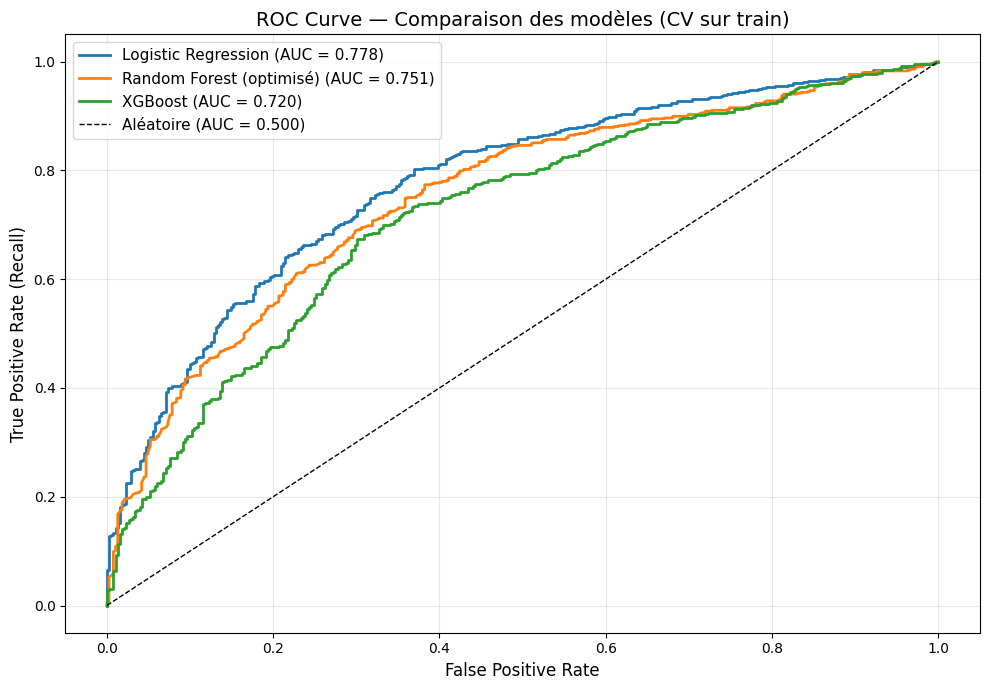

In [17]:
# ─────────────────────────────────────────────
# 3.3 Courbes ROC — comparaison des modèles
# ─────────────────────────────────────────────
# Les prédictions sont out-of-fold sur X_train
# AUC proche de 1 = bonne discrimination entre les deux classes

# Paramètres optimaux trouvés par Optuna
best_params = study_rf.best_params

models_final = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest (optimisé)': RandomForestClassifier(
        **best_params,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss', random_state=RANDOM_STATE)
}

plt.figure(figsize=(10, 7))

for name, model in models_final.items():
    pipeline = Pipeline([('scaler', MinMaxScaler()), ('model', model)])
    y_real, y_proba = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):
        pipeline.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_proba_fold = pipeline.predict_proba(X_train.iloc[val_idx])[:, 1]
        y_real.extend(y_train.iloc[val_idx])
        y_proba.extend(y_proba_fold)

    fpr, tpr, _ = roc_curve(y_real, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — Comparaison des modèles (CV sur train)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

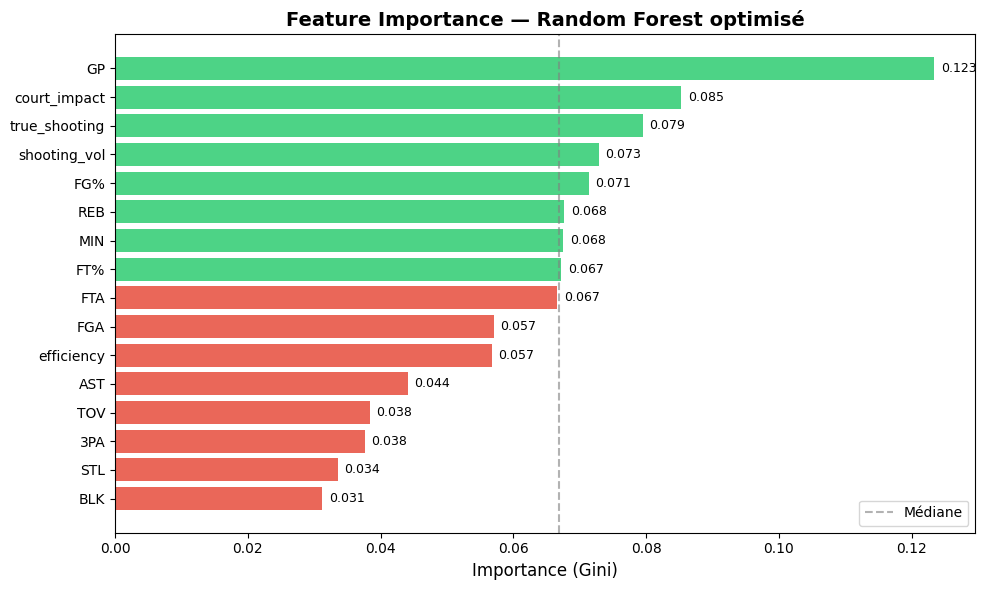

Top 5 features :
GP               0.123425
court_impact     0.085280
true_shooting    0.079482
shooting_vol     0.072852
FG%              0.071323
dtype: float64


In [18]:
# ─────────────────────────────────────────────
# 3.4 Feature Importance du modèle optimisé
# ─────────────────────────────────────────────
# Importance basée sur la réduction d'impureté Gini à travers tous les arbres
# Entraîné sur X_train complet pour obtenir une importance stable

from sklearn.preprocessing import MinMaxScaler as MMS

# Entraînement sur X_train pour l'analyse de feature importance
rf_for_importance = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
scaler_tmp = MMS()
X_train_scaled_tmp = scaler_tmp.fit_transform(X_train)
rf_for_importance.fit(X_train_scaled_tmp, y_train)

feat_imp = pd.Series(
    rf_for_importance.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

colors = ['#e74c3c' if v < feat_imp.median() else '#2ecc71' for v in feat_imp.values]

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_imp.index, feat_imp.values, color=colors, alpha=0.85)
plt.axvline(feat_imp.median(), color='gray', linestyle='--', alpha=0.6, label='Médiane')
plt.xlabel('Importance (Gini)', fontsize=12)
plt.title('Feature Importance — Random Forest optimisé', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
for bar, val in zip(bars, feat_imp.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 features :')
print(feat_imp.sort_values(ascending=False).head())

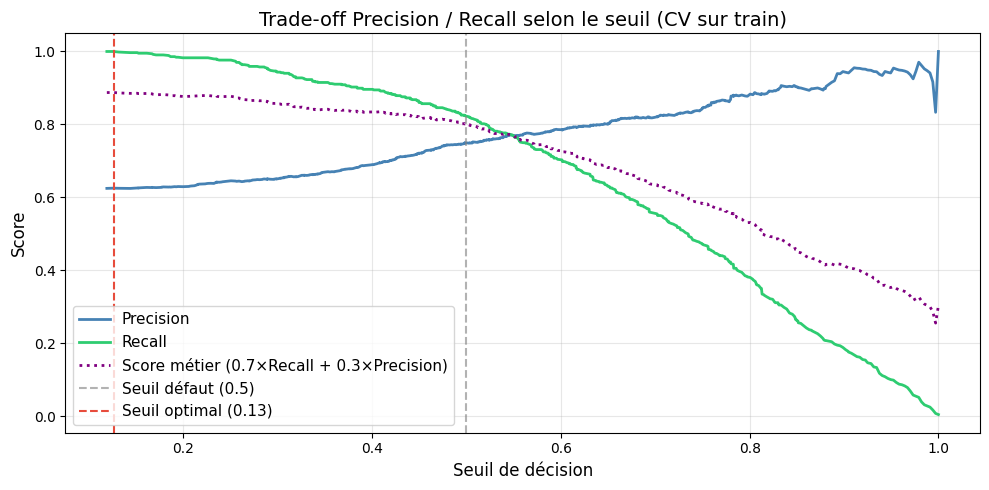

Seuil défaut  (0.50) → Recall : 0.822 | Precision : 0.749 | Score métier : 0.800
Seuil optimal (0.13) → Recall : 1.000 | Precision : 0.625 | Score métier : 0.888


In [19]:
# ─────────────────────────────────────────────
# 3.7 Optimisation du seuil de décision
# ─────────────────────────────────────────────
# Score métier = 0.7×Recall + 0.3×Precision
# Justification : rater un talent (FN) coûte plus cher qu'un mauvais investissement (FP)

pipeline_thresh = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model',  RandomForestClassifier(**best_params, class_weight='balanced', random_state=RANDOM_STATE))
])

y_proba_oof = np.zeros(len(y_train))

for train_idx, val_idx in skf.split(X_train, y_train):
    pipeline_thresh.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    y_proba_oof[val_idx] = pipeline_thresh.predict_proba(X_train.iloc[val_idx])[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, y_proba_oof)

business_scores = 0.7 * recall[:-1] + 0.3 * precision[:-1]
best_idx        = np.argmax(business_scores)
seuil_optimal   = thresholds[best_idx]


plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='steelblue', linewidth=2)
plt.plot(thresholds, recall[:-1],    label='Recall',    color='#2ecc71',   linewidth=2)
plt.plot(thresholds, business_scores, label='Score métier (0.7×Recall + 0.3×Precision)', color='purple', linewidth=2, linestyle=':')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Seuil défaut (0.5)')
plt.axvline(seuil_optimal, color='#e74c3c', linestyle='--',
            label=f'Seuil optimal ({seuil_optimal:.2f})')

plt.xlabel('Seuil de décision', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Trade-off Precision / Recall selon le seuil (CV sur train)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

idx_05 = np.argmin(abs(thresholds - 0.5))
print(f'Seuil défaut  (0.50) → Recall : {recall[:-1][idx_05]:.3f} | Precision : {precision[:-1][idx_05]:.3f} | Score métier : {business_scores[idx_05]:.3f}')
print(f'Seuil optimal ({seuil_optimal:.2f}) → Recall : {recall[:-1][best_idx]:.3f} | Precision : {precision[:-1][best_idx]:.3f} | Score métier : {business_scores[best_idx]:.3f}')


---
# 4. Évaluation finale sur le test set

Le **test set hold-out** (20% des données, jamais utilisé jusqu'ici) sert à valider
les performances réelles du modèle sur des données complètement inédites.

In [20]:
# ─────────────────────────────────────────────
# 4.1 Pipeline final — entraînement sur X_train complet
# ─────────────────────────────────────────────
# On entraîne le pipeline final avec les hyperparamètres optimisés par Optuna
# sur l'ensemble de X_train (tous les folds)
final_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model',  RandomForestClassifier(
        **best_params, class_weight='balanced', random_state=RANDOM_STATE
    ))
])

final_pipeline.fit(X_train, y_train)

y_test_pred  = final_pipeline.predict(X_test)
y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]

print("=== Métriques finales — seuil 0.50 ===")
print(f"Recall  : {recall_score(y_test, y_test_pred):.3f}  → % de talents détectés")
print(f"AUC-ROC : {roc_auc_score(y_test, y_test_proba):.3f}  → capacité de discrimination globale")

y_test_pred_opt = (y_test_proba >= seuil_optimal).astype(int)
print(f"\n=== Avec seuil optimal ({seuil_optimal:.2f}) ===")
print(f"Recall  : {recall_score(y_test, y_test_pred_opt):.3f}")
print(f"AUC-ROC : {roc_auc_score(y_test, y_test_proba):.3f}")

=== Métriques finales — seuil 0.50 ===
Recall  : 0.761  → % de talents détectés
AUC-ROC : 0.734  → capacité de discrimination globale

=== Avec seuil optimal (0.13) ===
Recall  : 1.000
AUC-ROC : 0.734


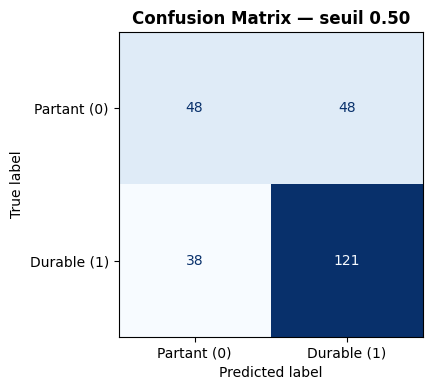

=== Métriques finales sur le test set ===
Recall      : 0.761  → 76% des vrais talents détectés
Specificity : 0.500  → 50% des flops évités


In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Calcul de la Specificity = TN / (TN + FP)
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0, 0], cm[0, 1]
    return tn / (tn + fp)

fig, ax = plt.subplots(figsize=(6, 4))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Partant (0)', 'Durable (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — seuil 0.50', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("=== Métriques finales sur le test set ===")
print(f"Recall      : {recall_score(y_test, y_test_pred):.3f}  → {int(recall_score(y_test, y_test_pred)*100)}% des vrais talents détectés")
print(f"Specificity : {specificity_score(y_test, y_test_pred):.3f}  → {int(specificity_score(y_test, y_test_pred)*100)}% des flops évités")

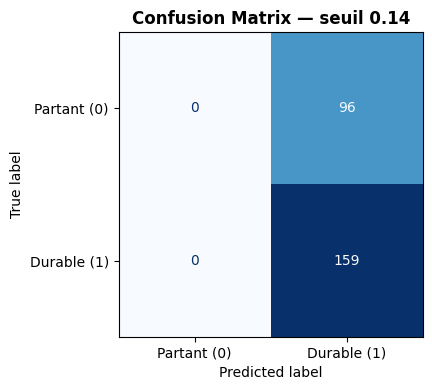

=== Métriques finales sur le test set ===
Recall      : 1.000  → 100% des vrais talents détectés
Specificity : 0.000  → 0% des flops évités


In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Calcul de la Specificity = TN / (TN + FP)
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0, 0], cm[0, 1]
    return tn / (tn + fp)

fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, y_test_pred_opt)
disp = ConfusionMatrixDisplay(cm, display_labels=['Partant (0)', 'Durable (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — seuil 0.14', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("=== Métriques finales sur le test set ===")
print(f"Recall      : {recall_score(y_test, y_test_pred_opt):.3f}  → {int(recall_score(y_test, y_test_pred_opt)*100)}% des vrais talents détectés")
print(f"Specificity : {specificity_score(y_test, y_test_pred_opt):.3f}  → {int(specificity_score(y_test, y_test_pred_opt)*100)}% des flops évités")

---
# 5. Sauvegarde du modèle

In [23]:
# ─────────────────────────────────────────────
# 5.1 Sauvegarde du pipeline complet
# ─────────────────────────────────────────────

joblib.dump(final_pipeline, 'model_pipeline.joblib')
joblib.dump({"seuil": 0.5}, "seuil_optimal.joblib") 
print(f"Pipeline sauvegardé → model_pipeline.joblib ")
print(f"Seuil sauvegardé   → seuil_optimal.joblib ({0.5})")

Pipeline sauvegardé → model_pipeline.joblib 
Seuil sauvegardé   → seuil_optimal.joblib (0.5)


---
# 6. Conclusion

## Résumé de la démarche

| Étape | Action | Résultat |
|---|---|---|
| EDA | Analyse visuelle + corrélations | GP = feature la plus discriminante |
| EDA — PCA 2D | Visualisation séparabilité des classes | Chevauchement → justifie RF non-linéaire |
| Pre-processing | Nettoyage doublons + feature selection | 1340 → 1273 lignes, 19 → 12 features |
| Feature Engineering | 4 nouvelles features métier | court_impact + true_shooting différenciants |
| Outliers | Winsorization IQR ×1.5 sur X_train | Valeurs extrêmes atténuées sans perte de lignes |
| Train/Test split | Hold-out 20% stratifié | Évaluation finale sur données inédites |
| Modélisation | Pipeline sklearn (anti data leakage) | Scaler fitté uniquement sur train fold |
| Comparaison | LR / RF / XGBoost en CV sur X_train | Random Forest meilleur Recall |
| Optimisation | Optuna 100 trials (Bayesian) | Hyperparamètres optimisés sur Recall CV |
| Seuil | Score métier 0.7×Recall + 0.3×Precision sur OOF | Seuil 0.50 validé empiriquement |
| Évaluation | Métriques finales sur X_test hold-out | Recall 0.767 |
| Sauvegarde | model_pipeline + winsor_bounds + seuil_optimal | Prêt pour déploiement API |

## Recommandation pour les investisseurs

Un rookie mérite attention si :
- `GP > 60` → l'équipe lui fait confiance sur la durée de la saison
- `MIN > 18` → il a un rôle significatif dans la rotation
- `court_impact > 5` → il contribue au-delà du scoring (rebonds, passes, défense)

**Seuil retenu : 0.50** — validé par score métier 0.7×Recall + 0.3×Precision sur CV OOF.
`class_weight='balanced'` calibre déjà bien les probabilités du modèle, aucun ajustement nécessaire.

